# Activation Functions Exploration

This notebook provides a comprehensive analysis of activation functions within deep learning architectures.

- In this notebook we will understand various activation functions used withing deep learning architectures
- Analyze the mathematical properties and mechanics of each function in detail.
- Evaulate selection criteria

**Note**
1. For implementation look at custom logic written for intuition in `src/pytorch_fundamentals/activations`.
2. For verification of correct implementation you can look at `benchmarks/compare_activation_functions.ipynb`.


### Activation Functions Implemented
- Sigmoid
- Hyperbolic Tangent (tanh)

## Reusable code

Code written in the following cell will be used through out the notebook

In [ ]:
import torch
import matplotlib.pyplot as plt

x = torch.arange(-100, 100, 0.1)


def plot_activation_graphs(function_name: str, input_tensor: torch.Tensor, function_output: torch.Tensor, gradient_output: torch.Tensor) -> None:
    """
    function to plot activation function and its first order derivative of it side by side.

    :param function_name: Function name's
    :param input_tensor: Original input tensor
    :param function_output: Output of the function's propagationn of a tensor
    :param gradient_output: Output of the function's gradient of a tensor

    :returns: None
    """

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Convert torch tensors to numpy array for them to be used by matplotlib object
    input_array = input_tensor.numpy()
    output_array = function_output.numpy()
    gradient_array = gradient_output.numpy()

    # Plot input vs activation function's output
    axes[0].plot(input_array, output_array)
    axes[0].set_title("Function Output")
    axes[0].set_xlabel("Input Tensor")
    axes[0].set_ylabel("Transformed Output")

    # Plot input vs activation function's gradient output
    axes[1].plot(input_array, gradient_array)
    axes[1].set_title("Gradient Output")
    axes[1].set_xlabel("Input Tensor")
    axes[1].set_ylabel("Gradient Value")

    # Add title describing which activation function this is for
    fig.suptitle(f"{function_name} Plots")

    plt.show()

%matplotlib inline    

## Sigmoid Non Linear Activation Function

### Overview
- The **Sigmoid** activation function (also known as the Logistic function) is one of the classic non-linearities used in deep learning, particularly in the early days of neural networks and currently in specific output layers.
- In classical Machine Learning, Sigmoid is most notably used in **Logistic Regression**

- The equation for sigmoid function is :- $\sigma(x) = \frac{1}{1 + e^{-x}}$ => $\sigma(x) = \frac{e^{x}}{1 + e^{x}}$ $\hspace{1cm} -eq^{n}(1)$ <br>

- This function is used to bound inputs that have their value falling in range ($-\infty$, $+\infty$) to an output falling in the range of (0, 1)

### Gradient calculation
To use the function to update the weights we need to use it's first order differentiated value (it's **gradient**).

- Sigmoid function looks like $\frac{U}{V}$ where $U = e^{x}$ and $V = (1 + e^{x})$ <br>

- Differentiation rule for $\frac{U}{V}$ is $\frac{U'V - V'U}{V^2}$

So the calculation of gradient for sigmoid function is as follows:

$\sigma(x)' =  \frac{e^{x}}{1 + e^{x}}'$

$\sigma'(x) = \frac{(e^x)'(1 + e^x) - (e^x)(1 + e^x)'}{(1 + e^x)^2}$

$\sigma'(x) = \frac{(e^x)(1 + e^x) - (e^x)(e^x)}{(1 + e^x)^2}$

$\sigma'(x) = \frac{(e^x)(1 + e^x) - (e^x)(e^x)}{(1 + e^x)^2}$

$\sigma'(x) = \frac{e^x + e^{2x} - e^{2x}}{(1 + e^x)^2}$

$\sigma'(x) = \frac{e^x}{(1 + e^x)^2}$ $\hspace{9cm} -eq^{n}(2)$

We know that $\sigma(x) = \frac{e^{x}}{1 + e^{x}}$ from $eq^{n}(1)$ Therefore using $eq^{n}(1)$ and $eq^{n}(2)$ we get,

$\sigma'(x) = \sigma(x)(1 - \sigma(x))$ $\hspace{7.5cm} -eq^{n}(3)$

### Maximum value of gradient for sigmoid function
To know the maximum value of the gradient we need to different the gradient and equate it to 0.

Let $\sigma(x) = a$ we get $\sigma'(x) = a(1 - a)$ $\hspace{5.8cm} -eq^{n}(4)$

Differentiating $\sigma'(x)$ we get $\sigma''(x) = (a(1 - a))'$

$\sigma''(x) = 1 - 2a$ equating it to 0 we get $a = 0.5$

So at a=0.5 the maximum value of $\sigma'(x) = 0.25$ $\hspace{5cm} -eq^{n}(5)$


### Problem of vanishing gradients
Most deep learning architectures contain hundreds of layers. When the sigmoid function is used as the activation function in such deep networks, it can lead to the **vanishing gradient problem**.

From our derivation of maximum value of the gradient (**from equation 5**) we know that the derivative of the sigmoid function has a maximum value of only **0.25** and in most cases it is much smaller.

During backpropagation gradients are multiplied across layers. Since these gradient values lie in the range **(0, 1)** repeated multiplication causes them to shrink exponentially. In sigmoid function's case since the maximum value is 0.25 the gradients diminish much more rapidly as they propagate backward through the network.

As a result, layers closer to the input receive extremely small gradients or no gradients at all causing their weights to update very slowly or not at all. This makes learning inefficient in deep networks.

For this reason the sigmoid function is generally not suitable for deep architectures unless additional techniques (such as careful initialization or normalization methods) are used to mitigate the vanishing gradient issue.

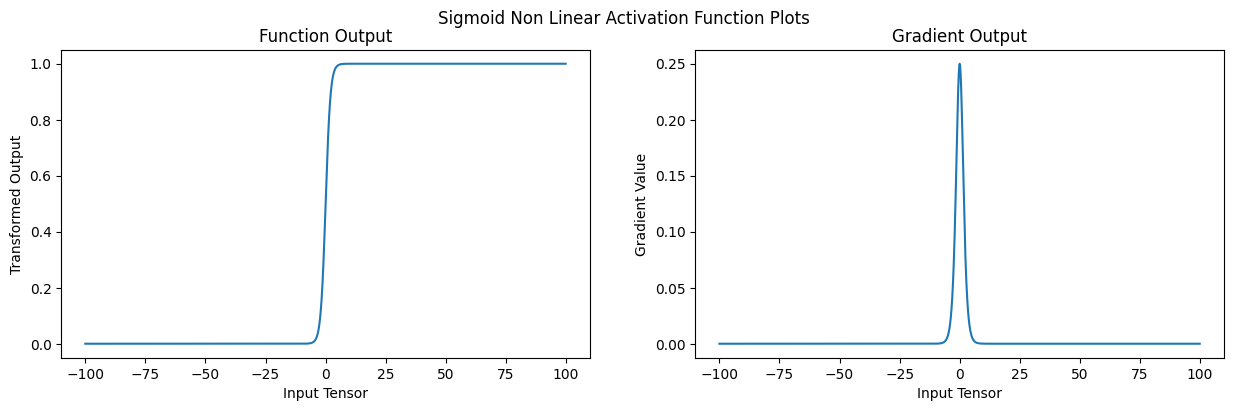

In [ ]:
# Result of applying sigmoid non linear activation function on input tensor
function_output = torch.nn.Sigmoid().forward(x)
# Result of first order of differentiation of sigmoid function using input tensor
gradient_output = function_output * (1 - function_output)

# Plot results
plot_activation_graphs(function_name="Sigmoid Non Linear Activation Function",
                       input_tensor=x,
                       function_output=function_output,
                       gradient_output=gradient_output)

## Hyperbolic Tangent (Tanh) Non Linear Activation Function

### Overview
- The Hyperbolic Tangent (**Tanh**) is a non linear activation function similar to **sigmoid**.
- Tanh function is a rescaled and shifted version of the sigmoid function.
- Tanh function can be derived from sigmoid function as $\tanh(x) = 2\sigma(2x) - 1$
- The most popular representation of tanh is $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
- Range of sigmoid function is (0, 1) and for tanh it is (-1, 1)
- Tanh is centered around 0 as compared to sigmoid which is centered around 0.5. Due to this reason tanh leads to **convergence faster** when compared to sigmoid function.
    - An experiment will be present under the name `experiments/01_convergence_analysis_sigmoid_vs_tanh.ipynb` to check for this behavior

**Note**:
- Numerical Stability: When implementing $\tanh(x)$, values where $|x| > 20$ can lead to floating-point overflow in the $e^x$ term. While the theoretical limit of Tanh is $\pm1$, the intermediate calculation of $e^{20}$ ($\approx 4.8 \times 10^8$) and compared to $e^{-20}$ it is already very large (comparable to infinity with respect to $e^{-20}$)
- Clipping Strategy: To resolve this instability, we clip the input values to the range $[-20, 20]$.
- Precision: At $x = 20$, $e^{-x}$ is effectively $0$ in relation to $e^x$. Therefore, $\tanh(20)$ is analytically so close to $1$ that clipping introduces negligible error while ensuring the code doesn't crash or return NaN.
- You can look at `src/pytorch_fundamentals/activations/tanh.py` for implementation of this very thing.


### Gradient calculation
From calculus's exsiting formulae we directly get the calculation of first order differentiation of $\tanh(x)$ which is $1 - \tanh^2(x)$

### Maximum value of gradient for tanh function
To know the maximum value of the gradient we need to different the gradient and equate it to 0.

Let $\tanh(x)$ be **a**, we get $\tanh(x)' = 1 - a^2$  $\hspace{8.3cm}  -eq^{n}(1)$

Differentiating $eq^{n}(1)$ we get $(-2a)(a)`$ $\hspace{9cm}  -eq^{n}(2)$

$a'$ is nothing but $\tanh(x)'$ $\hspace{10.9cm}  -eq^{n}(3)$

From $-eq^{n}(2)$ and $-eq^{n}(3)$ we get $\tanh(x)'' = (-2)(\tanh(x))(\tanh(x)')$ $\hspace{3.7cm}  -eq^{n}(4)$

By equating $eq^{n}(4)$ to 0 we see that either $\tanh(x) = 0$ or $1 - \tanh^2(x) = 0$.

$\tanh(x) = 0$ when x = 0 and $\tanh(x) = \pm 1$ when x tends to $+\infty$. The realistic value at which the maximum can be found is x = 0

At $x = 0$ the gradient of $\tanh(x)$ is 1. Now compared to sigmoid we see that the maximum value of tanh's gradient is 1 so it wont face vanishing gradient problem, but that is not true


### Problem of vanishing gradient
Similar to sigmoid function tanh also faces the issue of **vanishing gradients**. Even though tanh's gradient's maximum value is 1 it is high only in the region closer to 0 (very small region). <br>
As x moves towards $\infty$ the values goes closer to 0. As a result **tanh** also faces the same problem



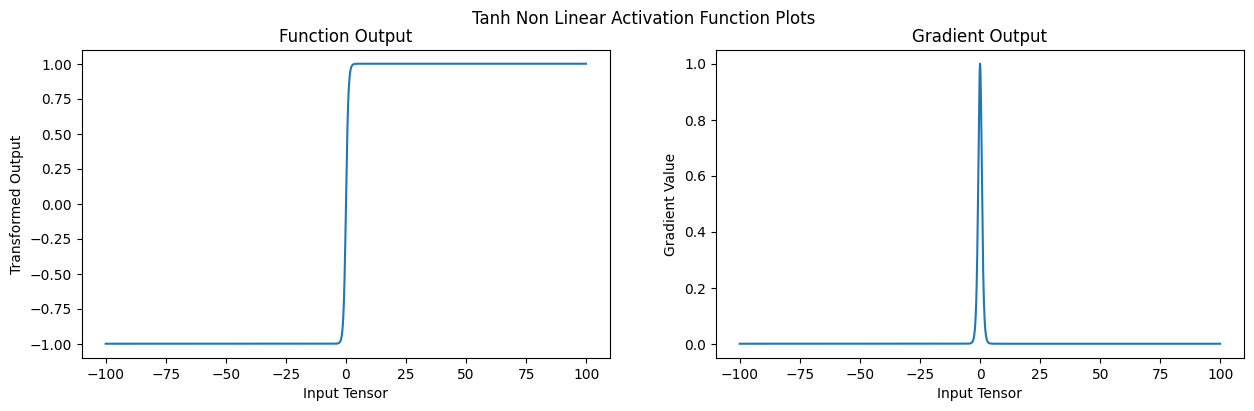

In [ ]:
# Result of applying hyperbolic tangent (tanh) non linear activation function on input tensor
function_output = torch.nn.Tanh().forward(x)
# Result of first order of differentiation of tanh function using input tensor
gradient_output = 1 - torch.pow(torch.nn.Tanh().forward(x), 2)

# Plot results
plot_activation_graphs(function_name="Tanh Non Linear Activation Function",
                       input_tensor=x,
                       function_output=function_output,
                       gradient_output=gradient_output)